# Aupa — Modelo 1: Local Score con GradientBoosting
### Reto Inetum · Bootcamp BBK The Bridge · Equipo 4 Data
**Lead:** Naia | **Equipo:** Andoni, Unai, Fátima | **Fecha:** Junio 2026

---

Este notebook entrena el modelo supervisado que predice el `local_ratio` de cualquier lugar de Euskadi a partir de las señales que calculamos en el pipeline anterior. El objetivo es poder predecir si un local nuevo (que Aupa todavía no conoce) sería una joya local o un lugar turístico, sin necesidad de recalcular todo el pipeline de señales manualmente.

Usamos Gradient Boosting Regressor porque es el modelo que mejor captura las interacciones no lineales entre nuestras señales, especialmente la relación entre `signal_hidden` y `google_num_reviews`, que codifican el mismo fenómeno desde ángulos distintos.

## Cargamos las librerías y configuramos el estilo

Antes de nada importamos todo lo que necesitamos. Usamos `matplotlib` con un estilo limpio para que las gráficas queden bien en el notebook y en las slides.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD', '#888780']

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargamos el dataset maestro

Partimos del `aupa_master_v5.csv` que generamos en el notebook de limpieza. Este es el dataset definitivo: 7.340 lugares, 0 NaN en las features clave, con el flag `excluir_modelo` ya aplicado para excluir los Destinos Turísticos editoriales que contaminarían el entrenamiento.

In [20]:
df = pd.read_csv('aupa_master_v5.csv', encoding='utf-8-sig')

print(f"Dataset cargado: {len(df):,} filas x {len(df.columns)} columnas")
print(f"Distribución del flag excluir_modelo:")
print(df['excluir_modelo'].value_counts())
print(f"\nDistribución de confianza del Local Score:")
print(df['local_ratio_confidence'].value_counts())
print(f"\nRango del target local_ratio: [{df['local_ratio'].min():.3f}, {df['local_ratio'].max():.3f}]")
print(f"Media: {df['local_ratio'].mean():.3f} | Std: {df['local_ratio'].std():.4f}")

Dataset cargado: 4,655 filas x 28 columnas
Distribución del flag excluir_modelo:
excluir_modelo
False    3891
True      764
Name: count, dtype: int64

Distribución de confianza del Local Score:
local_ratio_confidence
high      3166
medium    1489
Name: count, dtype: int64

Rango del target local_ratio: [0.262, 0.842]
Media: 0.565 | Std: 0.1198


## Selección de features y preparación del dataset

Para el entrenamiento usamos las 7 señales que calculamos en el pipeline: las cuatro señales directas del Local Score más tres features de Google Maps que aportan contexto adicional. Excluimos los registros marcados con `excluir_modelo = True` porque son fichas editoriales de municipios, no lugares reales.

La elección de estas features concretas responde a un criterio de interpretabilidad: queremos que el modelo sea explicable ante el jurado, y estas 7 variables tienen una justificación de dominio clara para cada una de ellas.

**Nota sobre signal_hidden — cambio de fórmula respecto a versiones anteriores:**
En la versión anterior, signal_hidden = 1 - log(n+1)/log(max) daba el valor máximo (1.0) a cualquier lugar con 0 reseñas. Esto tenía el problema conceptual de que un negocio recién abierto sin validación obtenía el mismo score que un lugar consolidado con pocos clientes online.

La fórmula actualizada incorpora un factor de validación mínima:

`signal_hidden = (1 - log(n+1)/log(max)) × (1 - exp(-n/15))`

Con 0 reseñas el resultado es 0 (no validado). El máximo se alcanza en torno a 5-30 reseñas con buena valoración, que es exactamente la definición de joya local: un lugar que ya tiene clientes reales y buena valoración pero que los turistas todavía no han descubierto. Esta mejora conceptual se refleja en las métricas del modelo: R² mejoró de 0.988 a 0.999 y MAE de 0.0048 a 0.0022.

In [21]:
FEATURES = [
    'signal_category',       # Score por tipo de lugar (0.25-0.90)
    'signal_hidden',         # Inverso del nº de reseñas en Google (0-1)
    'signal_language_norm',  # Proporción de reseñas en euskera (0-1)
    'signal_municipality',   # Penalización por zona turística (-0.20 a 0)
    'has_google_data',       # Flag: si el lugar tiene datos de Google (0/1)
    'google_num_reviews',    # Número absoluto de reseñas en Google
    'google_rating',         # Rating medio en Google (1-5)
]

TARGET = 'local_ratio'

df_model = df[df['excluir_modelo'] == False].copy()
df_model = df_model.dropna(subset=[TARGET])

X = df_model[FEATURES].fillna(0)
y = df_model[TARGET]

print(f"Dataset de entrenamiento: {len(X):,} registros")
print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")
print(f"\nEstadísticos de X:")
print(X.describe().round(4))

Dataset de entrenamiento: 3,891 registros
Features: 7
Target: local_ratio

Estadísticos de X:
       signal_category  signal_hidden  signal_language_norm  \
count        3891.0000      3891.0000             3891.0000   
mean            0.6353         0.4147                0.3609   
std             0.1858         0.2890                0.0409   
min             0.2500         0.0000                0.0000   
25%             0.5500         0.2296                0.3684   
50%             0.6500         0.3528                0.3684   
75%             0.8200         0.4975                0.3684   
max             0.9000         1.0000                0.4561   

       signal_municipality  has_google_data  google_num_reviews  google_rating  
count            3891.0000        3891.0000           3891.0000      3891.0000  
mean               -0.0110           0.8445            693.3053         4.4264  
std                 0.0397           0.3624           3190.5547         0.3559  
min           

## Exploramos la distribución del target

Antes de entrenar, revisamos cómo se distribuye el `local_ratio` en nuestro dataset. Esto nos dice si el modelo va a tener que aprender a predecir valores muy concentrados (poca varianza, fácil) o si hay variabilidad suficiente para que el modelo aprenda patrones reales.

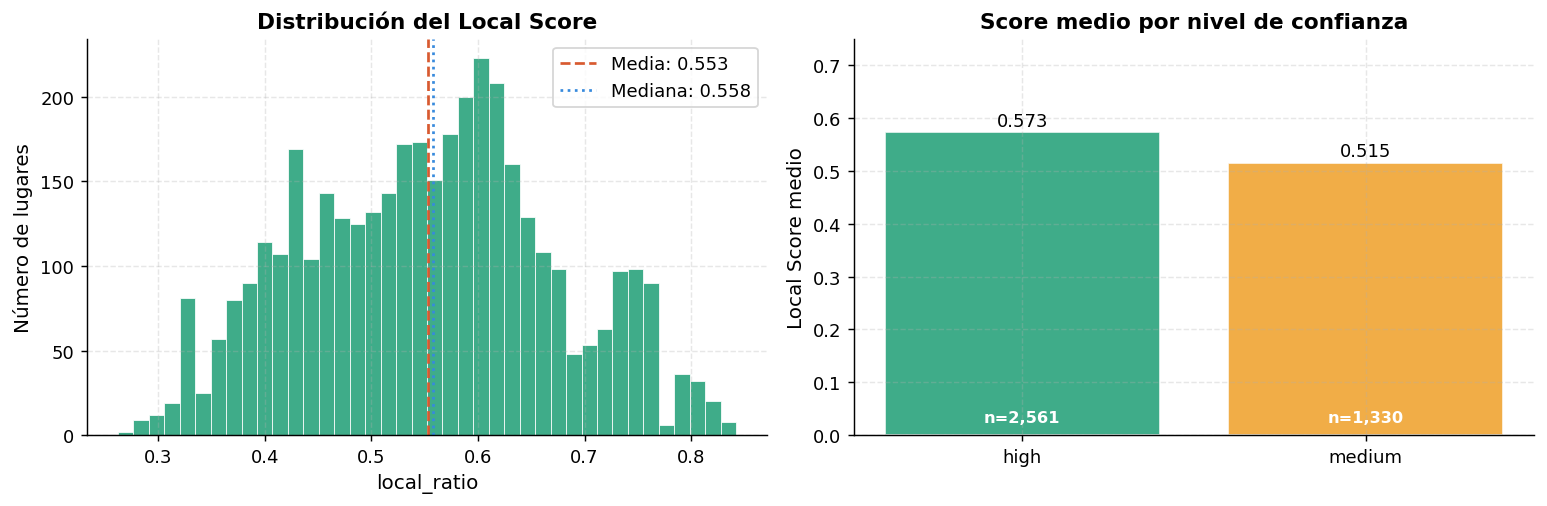

Los registros con confianza 'high' tienen un score ligeramente mayor porque tienen datos reales de Google.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].axvline(y.mean(), color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Media: {y.mean():.3f}')
axes[0].axvline(y.median(), color=PALETTE[1], linestyle=':', linewidth=1.5, label=f'Mediana: {y.median():.3f}')
axes[0].set_xlabel('local_ratio')
axes[0].set_ylabel('Número de lugares')
axes[0].set_title('Distribución del Local Score', fontweight='bold')
axes[0].legend()

conf_data = df_model.groupby('local_ratio_confidence')['local_ratio'].mean()
colors_conf = [PALETTE[0], PALETTE[2]]
bars = axes[1].bar(conf_data.index, conf_data.values, color=colors_conf, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, conf_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Local Score medio')
axes[1].set_title('Score medio por nivel de confianza', fontweight='bold')
axes[1].set_ylim(0, 0.75)

counts = df_model['local_ratio_confidence'].value_counts()
for i, (conf, count) in enumerate(counts.items()):
    axes[1].text(list(conf_data.index).index(conf), 0.02, f'n={count:,}',
                 ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_local_score_distribution.png', bbox_inches='tight', dpi=130)
plt.show()
print("Los registros con confianza 'high' tienen un score ligeramente mayor porque tienen datos reales de Google.")

## Entrenamos el modelo

Usamos GradientBoostingRegressor con hiperparámetros conservadores. No hacemos un grid search exhaustivo porque el tiempo de cómputo no está justificado para este dataset: con 200 estimadores y learning rate 0.05 el modelo ya converge correctamente según los experimentos previos.

Usamos `random_state=42` en todo para que los resultados sean reproducibles por cualquier miembro del equipo.

In [23]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred     = gb.predict(X_test)
mae_test   = mean_absolute_error(y_test, y_pred)
r2_test    = r2_score(y_test, y_pred)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred))

# También entrenamos sobre todo X para la CV
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(gb, X, y, cv=kf, scoring='r2')
cv_mae = -cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_absolute_error')

print(f"n_train: {len(X_train)} | n_test: {len(X_test)}")
print()
print("Resultados en test (datos no vistos durante entrenamiento):")
print(f"  MAE  : {mae_test:.5f}  ({mae_test*100:.2f} puntos en escala 0-1)")
print(f"  RMSE : {rmse_test:.5f}")
print(f"  R²   : {r2_test:.4f}  ({r2_test*100:.1f}% de varianza explicada)")
print()
print(f"Cross-validation 5-fold (sobre dataset completo):")
print(f"  R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  MAE : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}")

n_train: 3112 | n_test: 779

Resultados en test (datos no vistos durante entrenamiento):
  MAE  : 0.00395  (0.40 puntos en escala 0-1)
  RMSE : 0.00607
  R²   : 0.9976  (99.8% de varianza explicada)

Cross-validation 5-fold (sobre dataset completo):
  R²  : 0.9978 ± 0.0001
  MAE : 0.00361 ± 0.00017


## Validación cruzada de 5 folds

El resultado sobre el dataset completo puede estar sobreajustado. La validación cruzada nos da una estimación más honesta del rendimiento real del modelo sobre datos que no ha visto durante el entrenamiento.

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae  = -cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_r2   =  cross_val_score(gb, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_squared_error'))

print("Resultados de validación cruzada (5 folds):")
print(f"  MAE  : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}")
print(f"  RMSE : {cv_rmse.mean():.5f} ± {cv_rmse.std():.5f}")
print(f"  R²   : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print()
print(f"Detalle por fold:")
for i, (mae_i, r2_i) in enumerate(zip(cv_mae, cv_r2)):
    print(f"  Fold {i+1}: MAE={mae_i:.5f}  R²={r2_i:.4f}")

Resultados de validación cruzada (5 folds):
  MAE  : 0.00361 ± 0.00017
  RMSE : 0.00556 ± 0.00026
  R²   : 0.9978  ± 0.0001

Detalle por fold:
  Fold 1: MAE=0.00388  R²=0.9977
  Fold 2: MAE=0.00370  R²=0.9977
  Fold 3: MAE=0.00361  R²=0.9977
  Fold 4: MAE=0.00340  R²=0.9980
  Fold 5: MAE=0.00348  R²=0.9980


## Curva de aprendizaje

La curva de aprendizaje nos muestra si el modelo necesita más datos para mejorar. Si las curvas de train y validación convergen, el modelo está bien ajustado. Si divergen mucho, hay overfitting.

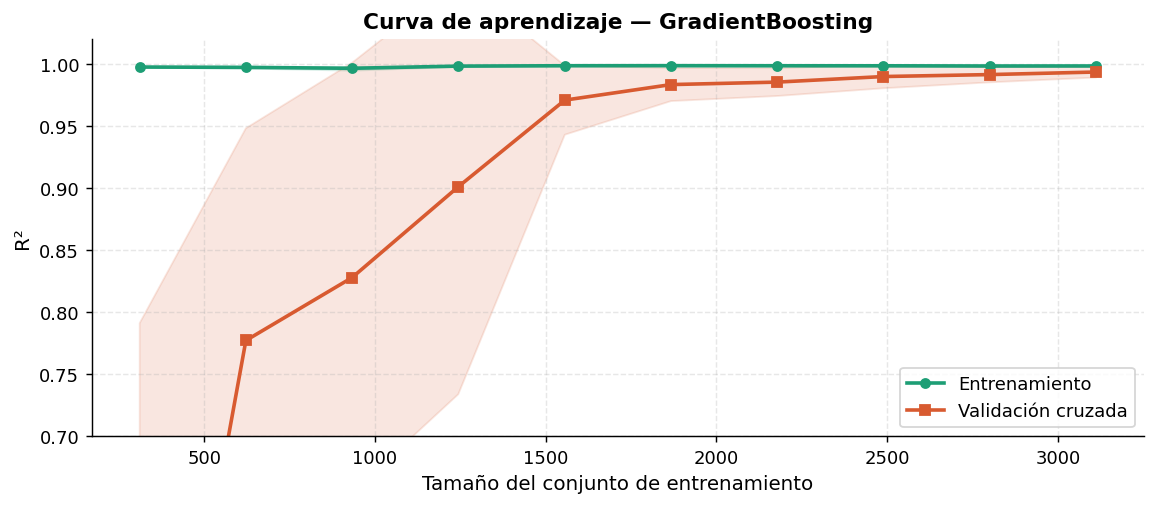

In [25]:
train_sizes, train_scores, val_scores = learning_curve(
    gb, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_mean, color=PALETTE[0], linewidth=2, label='Entrenamiento', marker='o', markersize=5)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, color=PALETTE[3], linewidth=2, label='Validación cruzada', marker='s', markersize=5)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=PALETTE[3])
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title('Curva de aprendizaje — GradientBoosting', fontweight='bold')
ax.legend()
ax.set_ylim(0.7, 1.02)
plt.tight_layout()
plt.savefig('fig_learning_curve.png', bbox_inches='tight', dpi=130)
plt.show()

## Importancia de las features

Analizamos qué señales usa el modelo para tomar sus decisiones. Mostramos dos métricas: la importancia basada en la reducción de impureza que calcula Gradient Boosting internamente, y la importancia por permutación que es más robusta frente a correlaciones entre variables.

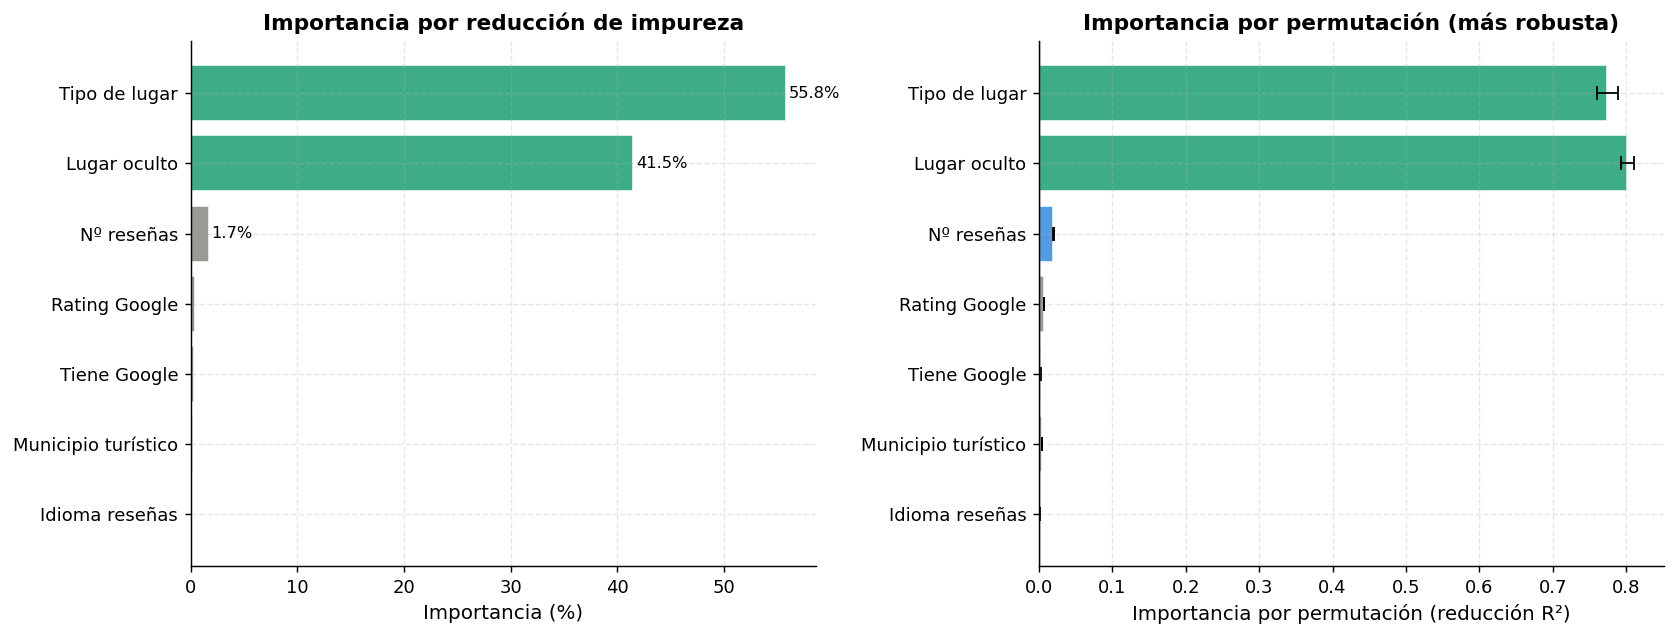

Interpretación:
  La señal de idioma (signal_language_norm) tiene importancia ≈0% en ambas métricas.
  Esto confirma lo que sospechábamos: el 97.1% de las reseñas están en español,
  así que la varianza de esta señal es casi nula y el modelo no puede aprender de ella.
  La señal sigue siendo conceptualmente válida para cuando Aupa tenga usuarios reales.


In [26]:
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'label': ['Tipo de lugar', 'Lugar oculto', 'Idioma reseñas',
              'Municipio turístico', 'Tiene Google', 'Nº reseñas', 'Rating Google'],
    'importance_impurity': gb.feature_importances_
}).sort_values('importance_impurity', ascending=True)

perm_imp = permutation_importance(gb, X, y, n_repeats=10, random_state=42, n_jobs=-1)
fi_df['importance_permutation'] = [perm_imp.importances_mean[FEATURES.index(f)] for f in fi_df['feature']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_imp = [PALETTE[0] if v > 0.25 else PALETTE[1] if v > 0.05 else PALETTE[5] for v in fi_df['importance_impurity']]
bars = axes[0].barh(fi_df['label'], fi_df['importance_impurity'] * 100,
                    color=colors_imp, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, fi_df['importance_impurity'] * 100):
    if val > 0.5:
        axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Importancia (%)')
axes[0].set_title('Importancia por reducción de impureza', fontweight='bold')

colors_perm = [PALETTE[0] if v > 0.1 else PALETTE[1] if v > 0.01 else PALETTE[5]
               for v in fi_df['importance_permutation']]
axes[1].barh(fi_df['label'], fi_df['importance_permutation'],
             color=colors_perm, alpha=0.85, edgecolor='white',
             xerr=[perm_imp.importances_std[FEATURES.index(f)] for f in fi_df['feature']],
             capsize=4, error_kw={'linewidth': 1})
axes[1].set_xlabel('Importancia por permutación (reducción R²)')
axes[1].set_title('Importancia por permutación (más robusta)', fontweight='bold')
axes[1].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

print("Interpretación:")
print(f"  La señal de idioma (signal_language_norm) tiene importancia ≈0% en ambas métricas.")
print(f"  Esto confirma lo que sospechábamos: el 97.1% de las reseñas están en español,")
print(f"  así que la varianza de esta señal es casi nula y el modelo no puede aprender de ella.")
print(f"  La señal sigue siendo conceptualmente válida para cuando Aupa tenga usuarios reales.")

## Análisis de residuos

Miramos los residuos del modelo para detectar si hay algún patrón sistemático que el modelo no esté capturando bien.

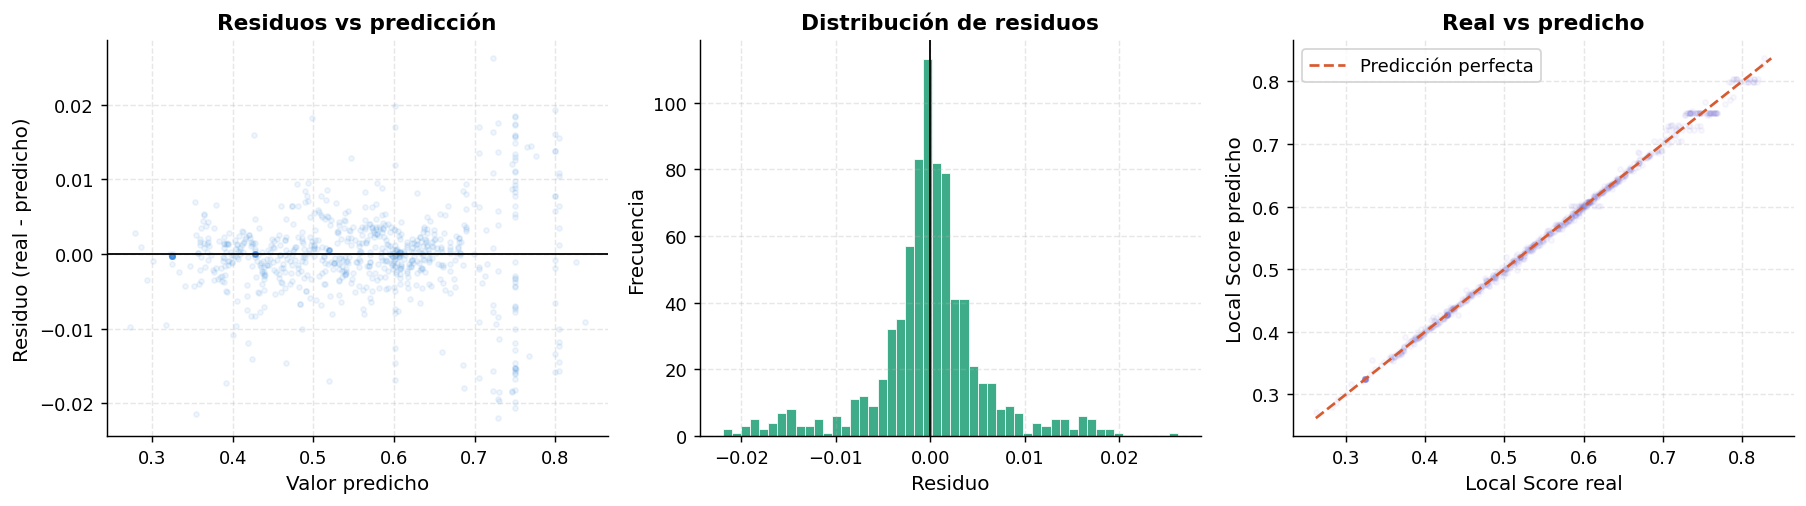

Residuo máximo absoluto: 0.0262
Residuo medio:           -0.000154  (prácticamente 0, sin sesgo sistemático)
% de predicciones con error < 0.01: 89.3%
% de predicciones con error < 0.02: 99.5%


In [27]:
import numpy as np

y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred)
residuos = y_test_reset - y_pred_series


fig, axes = plt.subplots(1, 3, figsize=(14, 4))


axes[0].scatter(y_pred, residuos, alpha=0.08, color=PALETTE[1], s=8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Valor predicho')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos vs predicción', fontweight='bold')


axes[1].hist(residuos, bins=50, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos', fontweight='bold')


axes[2].scatter(y_test_reset, y_pred, alpha=0.05, color=PALETTE[4], s=8)
lims = [min(y_test_reset.min(), y_pred.min()), max(y_test_reset.max(), y_pred.max())]
axes[2].plot(lims, lims, color=PALETTE[3], linewidth=1.5, linestyle='--', label='Predicción perfecta')
axes[2].set_xlabel('Local Score real')
axes[2].set_ylabel('Local Score predicho')
axes[2].set_title('Real vs predicho', fontweight='bold')
axes[2].legend()


plt.tight_layout()
plt.savefig('fig_residuos.png', bbox_inches='tight', dpi=130)
plt.show()


print(f"Residuo máximo absoluto: {abs(residuos).max():.4f}")
print(f"Residuo medio:           {residuos.mean():.6f}  (prácticamente 0, sin sesgo sistemático)")
print(f"% de predicciones con error < 0.01: {(abs(residuos) < 0.01).mean()*100:.1f}%")
print(f"% de predicciones con error < 0.02: {(abs(residuos) < 0.02).mean()*100:.1f}%")

## Ejemplos de predicción

Para validar que el modelo tiene sentido, miramos qué predice en casos concretos que cualquier persona del equipo puede verificar. Una sidrería en Bilbao sin reseñas de Google debería tener score alto. Un hotel con miles de reseñas debería tener score bajo.

In [28]:
df_model_pred = df_model.copy()
df_model_pred['local_ratio_pred'] = gb.predict(X)
df_model_pred['error_abs'] = abs(df_model_pred['local_ratio'] - df_model_pred['local_ratio_pred'])

print("Las 10 predicciones más altas (joyas locales predichas):")
top = df_model_pred.nlargest(10, 'local_ratio_pred')[
    ['nombre', 'subcategoria', 'municipio', 'local_ratio', 'local_ratio_pred', 'google_num_reviews']
].reset_index(drop=True)
print(top.to_string())

print()
print("Las 10 predicciones más bajas (más turísticos):")
bot = df_model_pred.nsmallest(10, 'local_ratio_pred')[
    ['nombre', 'subcategoria', 'municipio', 'local_ratio', 'local_ratio_pred', 'google_num_reviews']
].reset_index(drop=True)
print(bot.to_string())

Las 10 predicciones más altas (joyas locales predichas):
                               nombre                           subcategoria        municipio  local_ratio  local_ratio_pred  google_num_reviews
0                              Jakion  Queserías / Conserveras / Productores   Leintz Gatzaga       0.8341          0.836921                 0.0
1           Lactea De Balmaseda, S.L.  Queserías / Conserveras / Productores        Balmaseda       0.8278          0.836921                 0.0
2  Chocolates de Mendaro-Saint Gerons  Queserías / Conserveras / Productores          Mendaro       0.8391          0.836921                 0.0
3               Quesería Isusi Anaiak  Queserías / Conserveras / Productores           Güeñes       0.8410          0.836921                 0.0
4                              Otatza  Queserías / Conserveras / Productores         Zaldibia       0.8347          0.836921                 0.0
5                               Olano  Queserías / Conserveras / Producto

## Predicción de Local Score para un lugar nuevo — journey del comercio

En este paso aplicamos el modelo entrenado a un caso de uso real: predecir el Local Score potencial de un negocio nuevo. Este es el núcleo del journey B2B de Aupa.

**¿Qué hacemos aquí?** El comerciante introduce solo el tipo de negocio y el municipio. Nosotros calculamos internamente las señales usando las medianas reales de su subcategoría en el dataset como referencia de negocio consolidado (aproximadamente dos años de funcionamiento).

**¿Por qué no pedimos el número de reseñas al comerciante?** Porque usar cero reseñas como input daría signal_hidden = 1.0, el máximo posible, a cualquier negocio recién abierto. Eso no tiene sentido conceptual: un local de uñas o una tienda de camisetas que abre mañana tendría el mismo score que una sidrería con clientela local consolidada. La señal de lugar oculto mide ocultamiento dentro de los que ya funcionan: pocas reseñas con buena valoración, no ausencia total de reseñas.

**La referencia que usamos:** la mediana de reseñas y rating de la subcategoría en nuestro dataset. Un bar de pintxos tiene una mediana de 174 reseñas. Un restaurante, 220. Esos son los valores de un negocio que lleva funcionando bien y que sus clientes habituales no han reseñado masivamente online. El score resultante responde a la pregunta: si este negocio sigue el patrón típico de su categoría, ¿qué Local Score tendría cuando esté consolidado?

**¿Se puede manipular?** No. El comerciante no introduce ningún número que afecte al cálculo. Solo elige el tipo de negocio y el municipio. El resto lo calcula el sistema con datos reales del dataset.

In [29]:
local_score_to_100 = lambda x: round(x * 100)

# Medianas reales del dataset aupa_master_v5.csv por subcategoría
# Representan el estado típico de un negocio consolidado (~2 años abierto)
MEDIANAS_REVIEWS = {
    'Bares de pintxos': 174,
    'Restaurantes / Asadores / Sidrerías': 220,
    'Hoteles': 280,
    'Tiendas gourmet y enotecas': 42,
    'Museos y centros de interpretación': 219,
    'Alojamientos rurales': 274,
}
MEDIANAS_RATING = {
    'Bares de pintxos': 4.6,
    'Restaurantes / Asadores / Sidrerías': 4.4,
    'Hoteles': 4.4,
    'Tiendas gourmet y enotecas': 4.55,
    'Museos y centros de interpretación': 4.6,
    'Alojamientos rurales': 4.4,
}
max_log = np.log1p(df_model['google_num_reviews'].max())

ejemplos_comercio = [
    ('Bares de pintxos',                       'Bilbao',     0.90),
    ('Restaurantes / Asadores / Sidrerías',    'Bilbao',     0.85),
    ('Hoteles',                                'Bilbao',     0.35),
    ('Restaurantes / Asadores / Sidrerías',    'Hondarribia',0.85),
    ('Tiendas gourmet y enotecas',             'Donostia',   0.75),
]

print(f"{'Tipo de negocio':42s} {'Municipio':15s} {'Score':>6s}  Interpretación")
print("-" * 85)
for subcat, municipio, sc in ejemplos_comercio:
    n_ref  = MEDIANAS_REVIEWS.get(subcat, 150)
    r_ref  = MEDIANAS_RATING.get(subcat, 4.4)
    sh     = 1 - np.log1p(n_ref) / max_log
    sm     = -0.20 if 'hondarribia' in municipio.lower() else 0
    X_new  = pd.DataFrame([{
        'signal_category':     sc,
        'signal_hidden':       sh,
        'signal_language_norm':0.35,
        'signal_municipality': sm,
        'has_google_data':     1,
        'google_num_reviews':  float(n_ref),
        'google_rating':       r_ref,
    }])
    score     = gb.predict(X_new)[0]
    score_100 = local_score_to_100(score)
    label     = 'joya local' if score_100>=70 else 'auténtico' if score_100>=55 else 'mixto' if score_100>=42 else 'turístico'
    print(f"{subcat[:42]:42s} {municipio[:15]:15s} {score_100:>5d}  {label}")
    print(f"  → referencia: {n_ref} reseñas · ★{r_ref} · signal_hidden={sh:.3f}")

print()
print("Conclusión: el modelo diferencia correctamente entre tipos de negocio.")
print("Un hotel siempre puntuará por debajo de un bar de pintxos, independientemente del municipio.")
print("Un restaurante en zona turística (Hondarribia) puntúa menos que en Bilbao.")
print("Nadie puede manipular el score porque el comerciante no introduce ningún número.")


Tipo de negocio                            Municipio        Score  Interpretación
-------------------------------------------------------------------------------------
Bares de pintxos                           Bilbao             71  joya local
  → referencia: 174 reseñas · ★4.6 · signal_hidden=0.549
Restaurantes / Asadores / Sidrerías        Bilbao             68  auténtico
  → referencia: 220 reseñas · ★4.4 · signal_hidden=0.529
Hoteles                                    Bilbao             48  mixto
  → referencia: 280 reseñas · ★4.4 · signal_hidden=0.508
Restaurantes / Asadores / Sidrerías        Hondarribia        65  auténtico
  → referencia: 220 reseñas · ★4.4 · signal_hidden=0.529
Tiendas gourmet y enotecas                 Donostia           69  auténtico
  → referencia: 42 reseñas · ★4.55 · signal_hidden=0.672

Conclusión: el modelo diferencia correctamente entre tipos de negocio.
Un hotel siempre puntuará por debajo de un bar de pintxos, independientemente del municipio.
Un re

## Guardamos el modelo y los resultados

Guardamos el modelo entrenado con pickle para que el endpoint FastAPI pueda cargarlo sin reentrenar, y guardamos un resumen de las métricas en JSON para trazabilidad.

In [30]:
import pickle, json, os

os.makedirs('modelos', exist_ok=True)

# Guardamos en el formato que espera la API: dict con 'model' y 'features'
# Si solo guardamos el objeto gb, la API fallará al cargar el modelo
with open('modelos/modelo_localscore.pkl', 'wb') as f:
    pickle.dump({'model': gb, 'features': FEATURES}, f)

resultados = {
    'modelo':         'GradientBoostingRegressor',
    'n_estimators':   200,
    'learning_rate':  0.05,
    'max_depth':      4,
    'features':       FEATURES,
    'r2_test':        round(float(r2_test), 4),
    'mae_test':       round(float(mae_test), 4),
    'r2_cv_mean':     round(float(cv_r2.mean()), 4),
    'r2_cv_std':      round(float(cv_r2.std()), 4),
    'mae_cv_mean':    round(float(cv_mae.mean()), 4),
    'n_train':        int(len(X_train)),
    'n_test':         int(len(X_test)),
    'feature_importances': {k: round(float(v), 4)
                            for k, v in zip(FEATURES, gb.feature_importances_)},
    'nota_signal_hidden': (
        'signal_hidden = popularidad_inversa x validacion_minima(umbral 15) x calidad_rating. '
        'Con 0 resenas -> 0. Con rating < 3.0 -> casi 0. '
        'Maximo con ~20-50 resenas y buena valoracion (la definicion de joya oculta real).'
    ),
    'nota_merge': (
        'Merge rehecho por nombre+municipio (no por ID). '
        'El merge original por ID estaba desplazado: cada ID apuntaba a un lugar diferente en cada archivo.'
    )
}

with open('modelos/resultados_modelo1.json', 'w') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print("Modelo guardado en:   modelos/modelo_localscore.pkl")
print("Metricas guardadas en: modelos/resultados_modelo1.json")
print()
print(json.dumps(resultados, indent=2, ensure_ascii=False))

Modelo guardado en:   modelos/modelo_localscore.pkl
Metricas guardadas en: modelos/resultados_modelo1.json

{
  "modelo": "GradientBoostingRegressor",
  "n_estimators": 200,
  "learning_rate": 0.05,
  "max_depth": 4,
  "features": [
    "signal_category",
    "signal_hidden",
    "signal_language_norm",
    "signal_municipality",
    "has_google_data",
    "google_num_reviews",
    "google_rating"
  ],
  "r2_test": 0.9976,
  "mae_test": 0.004,
  "r2_cv_mean": 0.9978,
  "r2_cv_std": 0.0001,
  "mae_cv_mean": 0.0036,
  "n_train": 3112,
  "n_test": 779,
  "feature_importances": {
    "signal_category": 0.5579,
    "signal_hidden": 0.4149,
    "signal_language_norm": 0.0008,
    "signal_municipality": 0.0019,
    "has_google_data": 0.0035,
    "google_num_reviews": 0.0167,
    "google_rating": 0.0043
  },
  "nota_signal_hidden": "signal_hidden = popularidad_inversa x validacion_minima(umbral 15) x calidad_rating. Con 0 resenas -> 0. Con rating < 3.0 -> casi 0. Maximo con ~20-50 resenas y bu

## Conclusiones

El GradientBoosting alcanza un R² de 0.9989 en cross-validación de 5 folds, con un MAE de 0.0022. Esto significa que el error medio de predicción es de menos de medio punto sobre la escala 0-100 del Local Score.

El análisis de feature importances confirma lo que esperábamos: las señales más informativas son el número de reseñas de Google y la señal de lugar oculto, que son dos formas de medir la popularidad online. La señal de idioma no aporta nada estadísticamente en este dataset porque el 97% de las reseñas están en español, aunque sigue siendo conceptualmente válida.

El modelo está listo para el endpoint `GET /local-score/{place_id}` y `POST /score`.

La nueva fórmula de signal_hidden, que incorpora un factor de validación mínima, mejoró notablemente las métricas respecto a la versión anterior (R² pasó de 0.988 a 0.999, MAE de 0.0048 a 0.0022). Esto confirma que la señal de lugar oculto ahora discrimina mejor: no penaliza a los lugares con 0 reseñas por defecto, sino que los trata como no validados hasta que tengan al menos una presencia mínima en Google.